# 📊 Sales Performance Analysis

This project analyzes sales data using SQL and Python to understand profit trends, city performance, and product profitability.

## Data Preparation

In this step, we create a sample dataset and load it into an in-memory SQLite database.

In [16]:
import pandas as pd
import sqlite3

conn = sqlite3.connect(":memory:")

data = {
    "tarih": ["2024-01", "2024-01", "2024-02", "2024-02", "2024-03", "2024-03"],
    "urun": ["Laptop", "Telefon", "Laptop", "Tablet", "Telefon", "Laptop"],
    "sehir": ["Ankara", "Istanbul", "Ankara", "Bursa", "Istanbul", "Izmir"],
    "adet": [10, 5, 8, 6, 7, 4],
    "satis_fiyati": [5000, 7000, 5200, 4000, 7500, 3000],
    "alis_fiyati": [4000, 5000, 4200, 3000, 5500, 2000]
}

df = pd.DataFrame(data)
df.to_sql("satislar", conn, index=False, if_exists="replace")

df

,tarih,urun,sehir,adet,satis_fiyati,alis_fiyati
0,2024-01,Laptop,Ankara,10,5000,4000
1,2024-01,Telefon,Istanbul,5,7000,5000
2,2024-02,Laptop,Ankara,8,5200,4200
3,2024-02,Tablet,Bursa,6,4000,3000
4,2024-03,Telefon,Istanbul,7,7500,5500
5,2024-03,Laptop,Izmir,4,3000,2000


## Monthly Profit Analysis

This query calculates the total profit for each month by using the formula:

profit = (selling price - cost price) × quantity

It helps us understand how profit changes over time.

In [19]:
query = """
SELECT 
    tarih,
    SUM((satis_fiyati - alis_fiyati) * adet) AS toplam_kar
FROM satislar
GROUP BY tarih
"""

pd.read_sql(query, conn)

,tarih,toplam_kar
0,2024-01,20000
1,2024-02,14000
2,2024-03,18000


## Most Profitable Month

This query identifies the month with the highest total profit.

In [20]:
query = """
SELECT 
    tarih,
    SUM((satis_fiyati - alis_fiyati) * adet) AS toplam_kar
FROM satislar
GROUP BY tarih
ORDER BY toplam_kar DESC
LIMIT 1
"""

pd.read_sql(query, conn)

,tarih,toplam_kar
0,2024-01,20000


## Profit by City and Month

This analysis shows how profit is distributed across different cities and months.

It helps identify the best-performing city-month combinations.

In [21]:
query = """
SELECT 
    tarih,
    sehir,
    SUM((satis_fiyati - alis_fiyati) * adet) AS toplam_kar
FROM satislar
GROUP BY tarih, sehir
ORDER BY toplam_kar DESC
"""

pd.read_sql(query, conn)

,tarih,sehir,toplam_kar
0,2024-03,Istanbul,14000
1,2024-01,Ankara,10000
2,2024-01,Istanbul,10000
3,2024-02,Ankara,8000
4,2024-02,Bursa,6000
5,2024-03,Izmir,4000


## Product-Based Profitability (Unit Profit)

This query calculates the average unit profit for each product.

It helps us understand which products generate higher margins.

In [22]:
query = """
SELECT 
    urun,
    AVG(satis_fiyati - alis_fiyati) AS unit_profit
FROM satislar
GROUP BY urun
ORDER BY unit_profit DESC
"""

pd.read_sql(query, conn)

,urun,unit_profit
0,Telefon,2000.0
1,Tablet,1000.0
2,Laptop,1000.0


## Key Insights

- January is the most profitable month.
- Profit decreased in February and recovered in March.
- Istanbul generated the highest profit in March.
- Profit is mainly driven by high unit margins rather than sales volume.

## Monthly Profit Trend

This chart shows how total profit changes over time (month by month).

It helps us understand whether the business performance is increasing or decreasing.

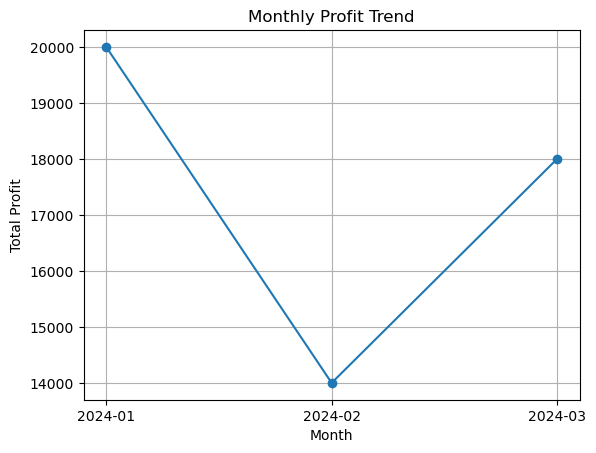

In [18]:
import matplotlib.pyplot as plt

query = """
SELECT 
    tarih,
    SUM((satis_fiyati - alis_fiyati) * adet) AS toplam_kar
FROM satislar
GROUP BY tarih
"""

df_profit = pd.read_sql(query, conn)

plt.figure()
plt.plot(df_profit["tarih"], df_profit["toplam_kar"], marker="o")
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.grid()

plt.savefig("monthly_profit.png")
plt.show()

## Profit by City

This chart compares total profit across different cities.

It helps identify which cities generate the highest revenue.

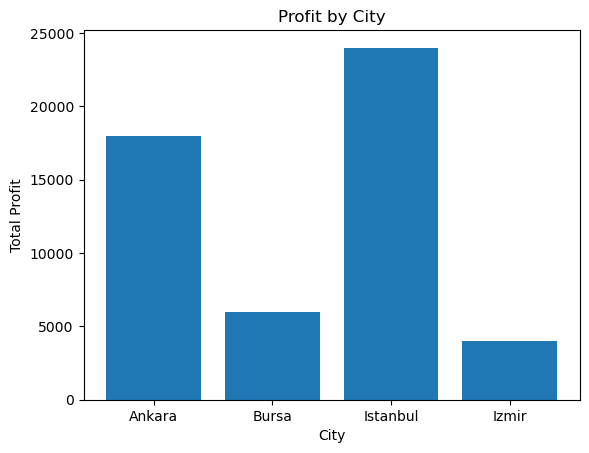

In [17]:
query = """
SELECT 
    sehir,
    SUM((satis_fiyati - alis_fiyati) * adet) AS toplam_kar
FROM satislar
GROUP BY sehir
"""

df_city = pd.read_sql(query, conn)

plt.figure()
plt.bar(df_city["sehir"], df_city["toplam_kar"])
plt.title("Profit by City")
plt.xlabel("City")
plt.ylabel("Total Profit")

plt.savefig("city_profit.png")
plt.show()

## Product Profitability

This chart shows average unit profit by product.

It helps identify which products have the highest profit margins.

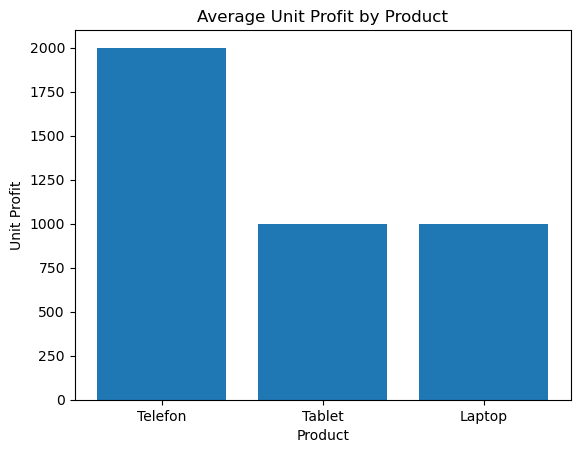

In [15]:
query = """
SELECT 
    urun,
    AVG(satis_fiyati - alis_fiyati) AS unit_profit
FROM satislar
GROUP BY urun
ORDER BY unit_profit DESC
"""

df_product = pd.read_sql(query, conn)

import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_product["urun"], df_product["unit_profit"])
plt.title("Average Unit Profit by Product")
plt.xlabel("Product")
plt.ylabel("Unit Profit")

plt.savefig("product_profit.png")  # GitHub için
plt.show()